In [ ]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Assuming my CSV file is in the 'data' folder within your Google Drive
file_path = '/content/drive/MyDrive/solar3/dataset.csv'

# Read the CSV file into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows of the DataFrame
df

,Absorber defect density,Series resistance,Shunt resistance,Reflection,Radiative recombination,Efficiency
0,1.000000e+12,1.0,10.0,0.05,1.000000e-06,1.43
1,1.000000e+12,1.0,10.0,0.05,1.000000e-07,1.95
2,1.000000e+12,1.0,10.0,0.05,1.000000e-10,2.07
3,1.000000e+12,1.0,10.0,0.05,1.000000e-11,2.07
4,1.000000e+12,1.0,10.0,0.15,1.000000e-06,1.15
...,...,...,...,...,...,...
1019,1.000000e+16,5.0,100000.0,0.20,1.000000e-11,11.50
1020,1.000000e+16,5.0,100000.0,0.25,1.000000e-06,5.97
1021,1.000000e+16,5.0,100000.0,0.25,1.000000e-07,9.69
1022,1.000000e+16,5.0,100000.0,0.25,1.000000e-10,10.80


In [ ]:
df.rename(columns=lambda x: x.strip(), inplace=True)
print(df.columns.tolist())


['Absorber defect density', 'Series resistance', 'Shunt resistance', 'Reflection', 'Radiative recombination', 'Efficiency']


# **RF feature importance technique**

Feature Importances:

                   Feature  Importance
2         Shunt resistance    0.703416
4  Radiative recombination    0.189300
0  Absorber defect density    0.068684
3               Reflection    0.030345
1        Series resistance    0.008255


<ipython-input-15-4caf169c3916>:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(feature_importance_df["Feature"], fontweight='bold')  # Make bold


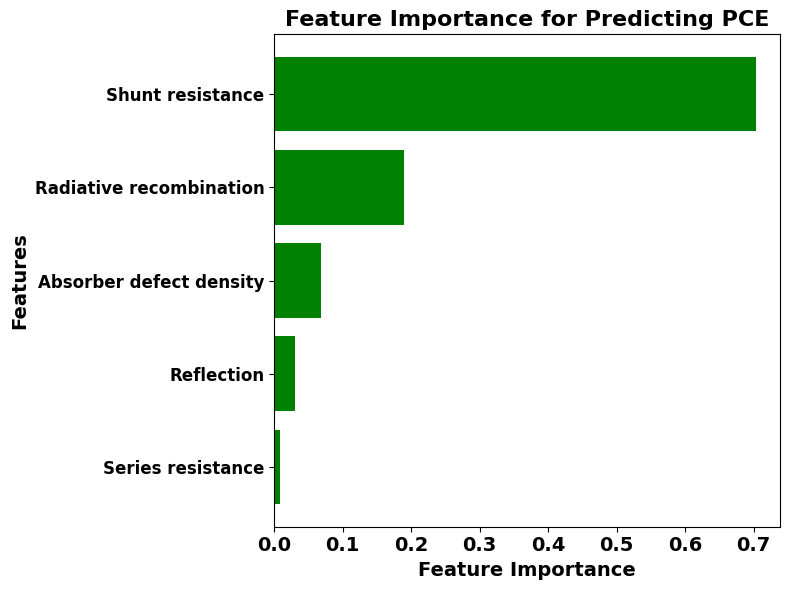


Feature importance plot saved at /content/drive/MyDrive/solar3/feature_importance.png


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Clean column names by stripping trailing or leading spaces
df.columns = df.columns.str.strip()

# Separate features and target
X = df.drop(columns=["Efficiency"])
y = df["Efficiency"]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

# Get feature importances
importances = model.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Print the feature importance DataFrame
print("Feature Importances:\n")
print(feature_importance_df)

# Plot the feature importances
plt.figure(figsize=(8, 6))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"], color="green")
plt.xlabel("Feature Importance", fontsize=14, fontweight="bold")
plt.ylabel("Features", fontsize=14, fontweight="bold")
plt.title("Feature Importance for Predicting PCE", fontsize=16, fontweight="bold")
plt.gca().invert_yaxis()

# Make y-tick labels bold and larger
plt.tick_params(axis='y', labelsize=12)  # Increase font size
plt.xticks(fontsize=14, fontweight='bold')
plt.gca().set_yticklabels(feature_importance_df["Feature"], fontweight='bold')  # Make bold

# Save the plot as an image in 300 DPI
image_path = '/content/drive/MyDrive/solar3/feature_importance.png'
plt.savefig(image_path, dpi=300, bbox_inches="tight")
plt.tight_layout()
# Show the plot
plt.show()

print(f"\nFeature importance plot saved at {image_path}")


# **Correlation Analysis**

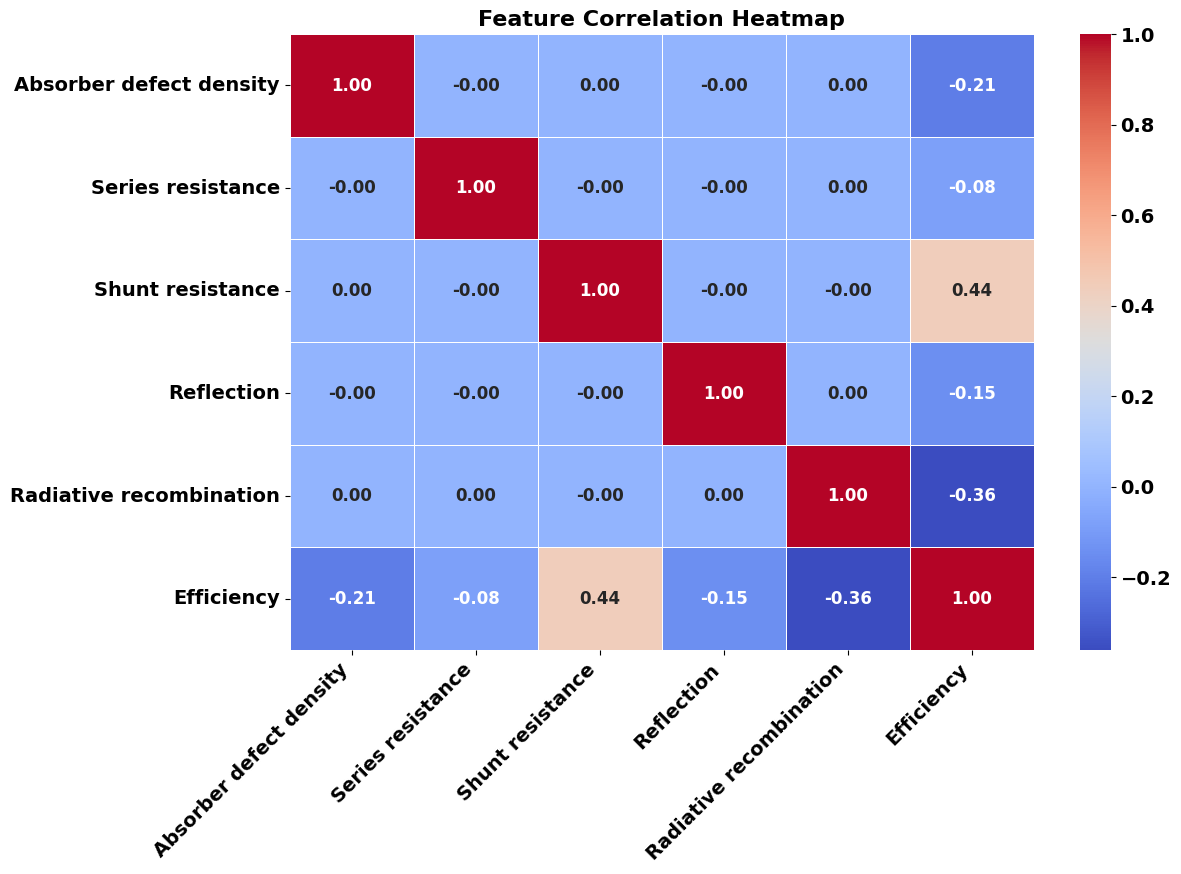

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
heatmap = sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    annot_kws={"size": 12, "weight": "bold"}  # Increase size and boldness of internal values
)

# Set title
plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')

# Set x and y axis labels font size and bold
plt.xticks(fontsize=14, fontweight='bold', rotation=45, ha='right')
plt.yticks(fontsize=14, fontweight='bold')

# Save the plot as an image in 300 DPI
image_path = '/content/drive/MyDrive/solar3/correlation.png'
plt.savefig(image_path, dpi=300, bbox_inches="tight")
plt.show()


# **Final RF**

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

Training Metrics:
Mean Squared Error (MSE): 0.0037
Root Mean Squared Error (RMSE): 0.0606
Mean Absolute Error (MAE): 0.0385
R² Score: 0.9999
Explained Variance Score: 0.9999

Test Metrics:
Mean Squared Error (MSE): 0.0249
Root Mean Squared Error (RMSE): 0.1579
Mean Absolute Error (MAE): 0.1048
R² Score: 0.9994
Explained Variance Score: 0.9994

The model does not exhibit significant overfitting.


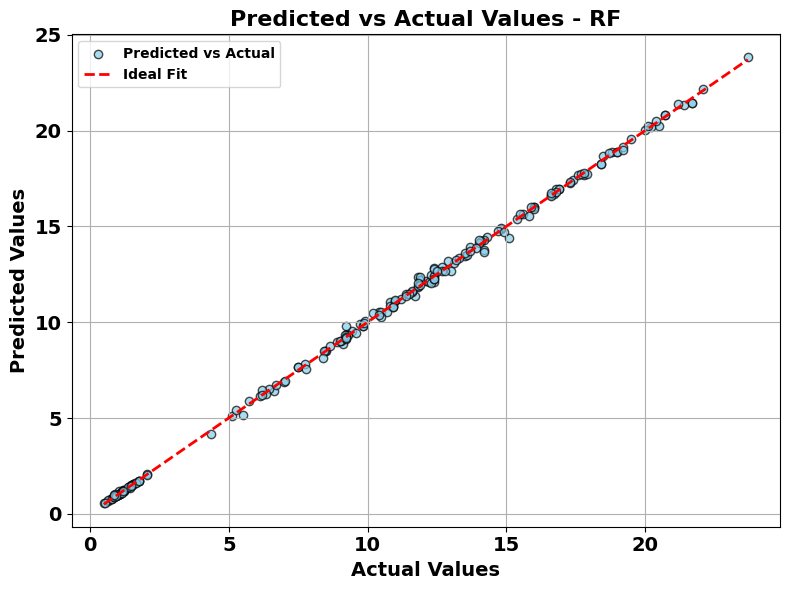

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
# Example: df = pd.read_csv("/content/drive/MyDrive/solar/solar3/your_dataset.csv")
# Make sure the target column is named "Efficiency"

# Define features and target
X = df.drop(columns=["Efficiency"])
y = df["Efficiency"]

# Split the dataset into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrame for model compatibility
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Grid Search CV for Random Forest
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5, 10]
}

rf = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled_df, y_train)

# Best model and parameters
best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# Predict on train and test sets
y_train_pred = best_model.predict(X_train_scaled_df)
y_test_pred = best_model.predict(X_test_scaled_df)

# Evaluation function
def evaluate_model(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    explained_variance = explained_variance_score(y_true, y_pred)

    print(f"\n{dataset_name} Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"R² Score: {r2:.4f}")
    print(f"Explained Variance Score: {explained_variance:.4f}")

    return mse, rmse, mae, r2, explained_variance

# Evaluate on training data
train_metrics = evaluate_model(y_train, y_train_pred, "Training")

# Evaluate on test data
test_metrics = evaluate_model(y_test, y_test_pred, "Test")

# Overfitting check
if abs(train_metrics[3] - test_metrics[3]) < 0.05:
    print("\nThe model does not exhibit significant overfitting.")
else:
    print("\nThe model may be overfitting.")


# Plot predicted vs actual values for the model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, color='skyblue', edgecolor='black', alpha=0.7, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.title('Predicted vs Actual Values - RF', fontsize=16, fontweight='bold')
plt.xlabel('Actual Values', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Values', fontsize=14, fontweight='bold')
plt.legend(fontsize=16, prop={'weight': 'bold'})
plt.grid(True)
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/solar3/True_vs_Predicted_RF.png", dpi=300)
plt.show()



# **SVR**

Best Parameters: {'C': 10, 'epsilon': 0.5, 'kernel': 'rbf'}

Training Metrics:
Mean Squared Error (MSE): 19.7005
Root Mean Squared Error (RMSE): 4.4385
Mean Absolute Error (MAE): 2.5901
R² Score: 0.5039
Explained Variance Score: 0.5794

Test Metrics:
Mean Squared Error (MSE): 21.6224
Root Mean Squared Error (RMSE): 4.6500
Mean Absolute Error (MAE): 2.6929
R² Score: 0.4565
Explained Variance Score: 0.5339

The model does not exhibit significant overfitting.


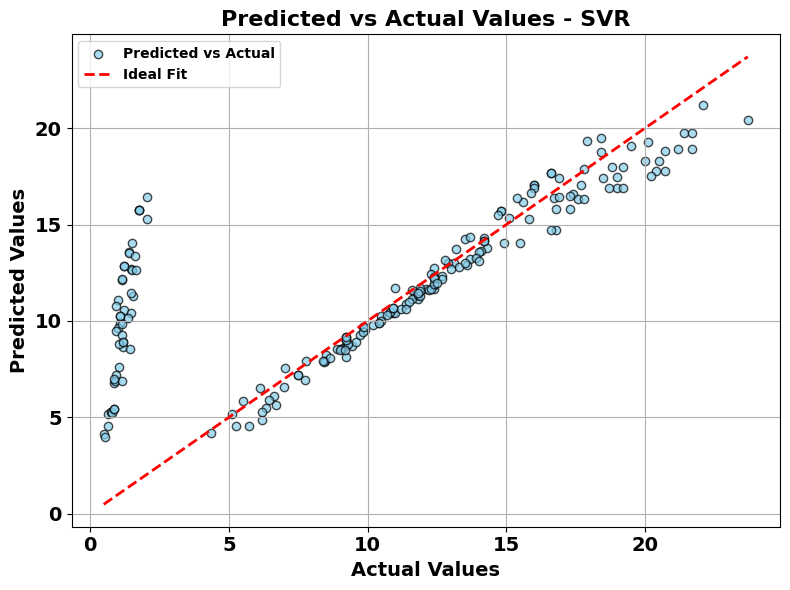

In [ ]:
import pandas as pd
import numpy as np
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
# Example: df = pd.read_csv("/content/drive/MyDrive/solar/solar3/your_dataset.csv")
# Ensure the target column is named "Efficiency"

# Define features and target
X = df.drop(columns=["Efficiency"])
y = df["Efficiency"]

# Split the dataset into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrame for model compatibility
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Grid Search CV for SVM (SVR)
param_grid = {
    "C": [0.1, 1, 10],
    "epsilon": [0.01, 0.1, 0.5],
    "kernel": ["rbf", "linear"]
}

svr = SVR()
grid_search = GridSearchCV(estimator=svr, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled_df, y_train)

# Best model and parameters
best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# Predict on train and test sets
y_train_pred = best_model.predict(X_train_scaled_df)
y_test_pred = best_model.predict(X_test_scaled_df)

# Evaluation function
def evaluate_model(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    explained_variance = explained_variance_score(y_true, y_pred)

    print(f"\n{dataset_name} Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"R² Score: {r2:.4f}")
    print(f"Explained Variance Score: {explained_variance:.4f}")

    return mse, rmse, mae, r2, explained_variance

# Evaluate on training data
train_metrics = evaluate_model(y_train, y_train_pred, "Training")

# Evaluate on test data
test_metrics = evaluate_model(y_test, y_test_pred, "Test")

# Overfitting check
if abs(train_metrics[3] - test_metrics[3]) < 0.05:
    print("\nThe model does not exhibit significant overfitting.")
else:
    print("\nThe model may be overfitting.")

# Plot predicted vs actual values for the model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, color='skyblue', edgecolor='black', alpha=0.7, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.title('Predicted vs Actual Values - SVR', fontsize=16, fontweight='bold')
plt.xlabel('Actual Values', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Values', fontsize=14, fontweight='bold')
plt.legend(fontsize=16, prop={'weight': 'bold'})
plt.grid(True)
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/solar3/True_vs_Predicted_SVM.png", dpi=300)
plt.show()



# **GBR**

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}

Training Metrics:
Mean Squared Error (MSE): 0.0006
Root Mean Squared Error (RMSE): 0.0255
Mean Absolute Error (MAE): 0.0181
R² Score: 1.0000
Explained Variance Score: 1.0000

Test Metrics:
Mean Squared Error (MSE): 0.0049
Root Mean Squared Error (RMSE): 0.0698
Mean Absolute Error (MAE): 0.0489
R² Score: 0.9999
Explained Variance Score: 0.9999

The model does not exhibit significant overfitting.


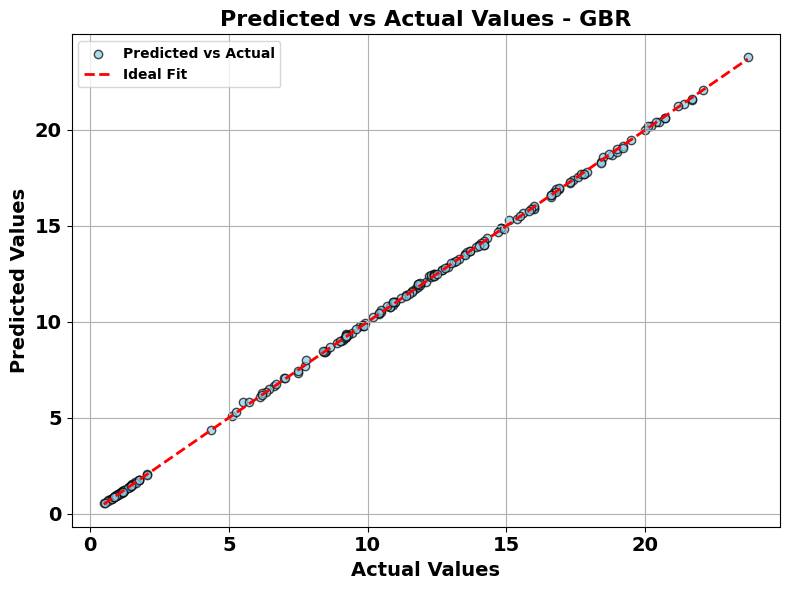

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
# Example: df = pd.read_csv("/content/drive/MyDrive/solar/solar3/your_dataset.csv")
# Make sure the target column is named "Efficiency"

# Define features and target
X = df.drop(columns=["Efficiency"])
y = df["Efficiency"]

# Split the dataset into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Grid Search CV for Gradient Boosting
param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, 7]
}

gbr = GradientBoostingRegressor(random_state=42)
grid_search = GridSearchCV(estimator=gbr, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled_df, y_train)

# Best model and parameters
best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# Predict on train and test sets
y_train_pred = best_model.predict(X_train_scaled_df)
y_test_pred = best_model.predict(X_test_scaled_df)

# Evaluation function
def evaluate_model(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    explained_variance = explained_variance_score(y_true, y_pred)

    print(f"\n{dataset_name} Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"R² Score: {r2:.4f}")
    print(f"Explained Variance Score: {explained_variance:.4f}")

    return mse, rmse, mae, r2, explained_variance

# Evaluate on training data
train_metrics = evaluate_model(y_train, y_train_pred, "Training")

# Evaluate on test data
test_metrics = evaluate_model(y_test, y_test_pred, "Test")

# Overfitting check
if abs(train_metrics[3] - test_metrics[3]) < 0.05:
    print("\nThe model does not exhibit significant overfitting.")
else:
    print("\nThe model may be overfitting.")

# Plot predicted vs actual values for the model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, color='skyblue', edgecolor='black', alpha=0.7, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.title('Predicted vs Actual Values - GBR', fontsize=16, fontweight='bold')
plt.xlabel('Actual Values', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Values', fontsize=14, fontweight='bold')
plt.legend(fontsize=16, prop={'weight': 'bold'})
plt.grid(True)
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/solar3/True_vs_Predicted_GBR.png", dpi=300)
plt.show()



# **XGBoost Regressor**

Best Parameters: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}

Training Metrics:
Mean Squared Error (MSE): 0.0003
Root Mean Squared Error (RMSE): 0.0176
Mean Absolute Error (MAE): 0.0124
R² Score: 1.0000
Explained Variance Score: 1.0000

Test Metrics:
Mean Squared Error (MSE): 0.0038
Root Mean Squared Error (RMSE): 0.0615
Mean Absolute Error (MAE): 0.0443
R² Score: 0.9999
Explained Variance Score: 0.9999

The model does not exhibit significant overfitting.


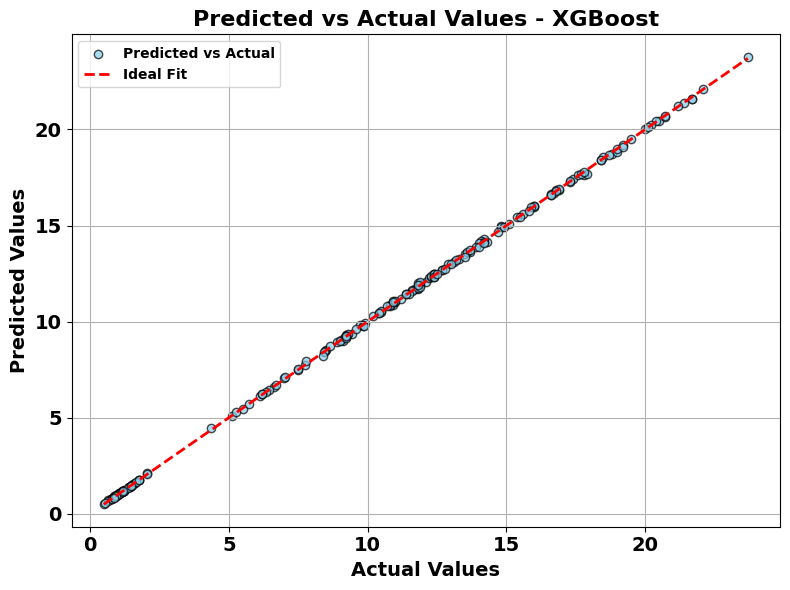

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
# Example: df = pd.read_csv("/content/drive/MyDrive/solar/solar3/your_dataset.csv")
# Ensure the target column is named "Efficiency"

# Define features and target
X = df.drop(columns=["Efficiency"])
y = df["Efficiency"]

# Split the dataset into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Grid Search CV for XGBoost
param_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 6],
    "subsample": [0.8, 1.0]
}

xgb = XGBRegressor(random_state=42, verbosity=0)
grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled_df, y_train)

# Best model and parameters
best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# Predict on train and test sets
y_train_pred = best_model.predict(X_train_scaled_df)
y_test_pred = best_model.predict(X_test_scaled_df)

# Evaluation function
def evaluate_model(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    explained_variance = explained_variance_score(y_true, y_pred)

    print(f"\n{dataset_name} Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"R² Score: {r2:.4f}")
    print(f"Explained Variance Score: {explained_variance:.4f}")

    return mse, rmse, mae, r2, explained_variance

# Evaluate on training data
train_metrics = evaluate_model(y_train, y_train_pred, "Training")

# Evaluate on test data
test_metrics = evaluate_model(y_test, y_test_pred, "Test")

# Overfitting check
if abs(train_metrics[3] - test_metrics[3]) < 0.05:
    print("\nThe model does not exhibit significant overfitting.")
else:
    print("\nThe model may be overfitting.")

# Plot predicted vs actual values for the model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, color='skyblue', edgecolor='black', alpha=0.7, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.title('Predicted vs Actual Values - XGBoost', fontsize=16, fontweight='bold')
plt.xlabel('Actual Values', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Values', fontsize=14, fontweight='bold')
plt.legend(fontsize=16, prop={'weight': 'bold'})
plt.grid(True)
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/solar3/True_vs_Predicted_XGB.png", dpi=300)
plt.show()



# **MLPR**

Best Parameters: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'learning_rate': 'constant', 'solver': 'adam'}

Training Metrics:
Mean Squared Error (MSE): 12.1177
Root Mean Squared Error (RMSE): 3.4810
Mean Absolute Error (MAE): 2.7426
R² Score: 0.6949
Explained Variance Score: 0.6958

Test Metrics:
Mean Squared Error (MSE): 13.0723
Root Mean Squared Error (RMSE): 3.6156
Mean Absolute Error (MAE): 2.7828
R² Score: 0.6714
Explained Variance Score: 0.6723

The model does not exhibit significant overfitting.


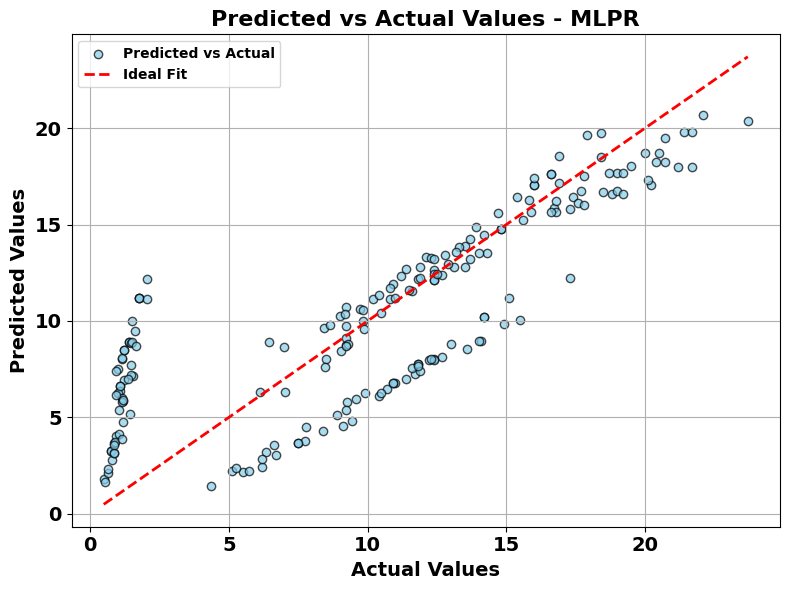

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
# Example: df = pd.read_csv("/content/drive/MyDrive/solar/solar3/your_dataset.csv")
# Ensure the target column is named "Efficiency"

# Define features and target
X = df.drop(columns=["Efficiency"])
y = df["Efficiency"]

# Split the dataset into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Grid Search CV for MLP
param_grid = {
    "hidden_layer_sizes": [(100,), (100, 50), (150, 100, 50)],
    "activation": ["relu", "tanh"],
    "solver": ["adam"],
    "alpha": [0.0001, 0.001],
    "learning_rate": ["constant", "adaptive"]
}

mlp = MLPRegressor(max_iter=1000, random_state=42)
grid_search = GridSearchCV(estimator=mlp, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled_df, y_train)

# Best model and parameters
best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# Predict on train and test sets
y_train_pred = best_model.predict(X_train_scaled_df)
y_test_pred = best_model.predict(X_test_scaled_df)

# Evaluation function
def evaluate_model(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    explained_variance = explained_variance_score(y_true, y_pred)

    print(f"\n{dataset_name} Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"R² Score: {r2:.4f}")
    print(f"Explained Variance Score: {explained_variance:.4f}")

    return mse, rmse, mae, r2, explained_variance

# Evaluate on training data
train_metrics = evaluate_model(y_train, y_train_pred, "Training")

# Evaluate on test data
test_metrics = evaluate_model(y_test, y_test_pred, "Test")

# Overfitting check
if abs(train_metrics[3] - test_metrics[3]) < 0.05:
    print("\nThe model does not exhibit significant overfitting.")
else:
    print("\nThe model may be overfitting.")

# Plot predicted vs actual values for the model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, color='skyblue', edgecolor='black', alpha=0.7, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.title('Predicted vs Actual Values - MLPR', fontsize=16, fontweight='bold')
plt.xlabel('Actual Values', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Values', fontsize=14, fontweight='bold')
plt.legend(fontsize=16, prop={'weight': 'bold'})
plt.grid(True)
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/solar3/True_vs_Predicted_MLP.png", dpi=300)
plt.show()


# **LightGBM Regressor**

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000049 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 25
[LightGBM] [Info] Number of data points in the train set: 819, number of used features: 5
[LightGBM] [Info] Start training from score 9.834756
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

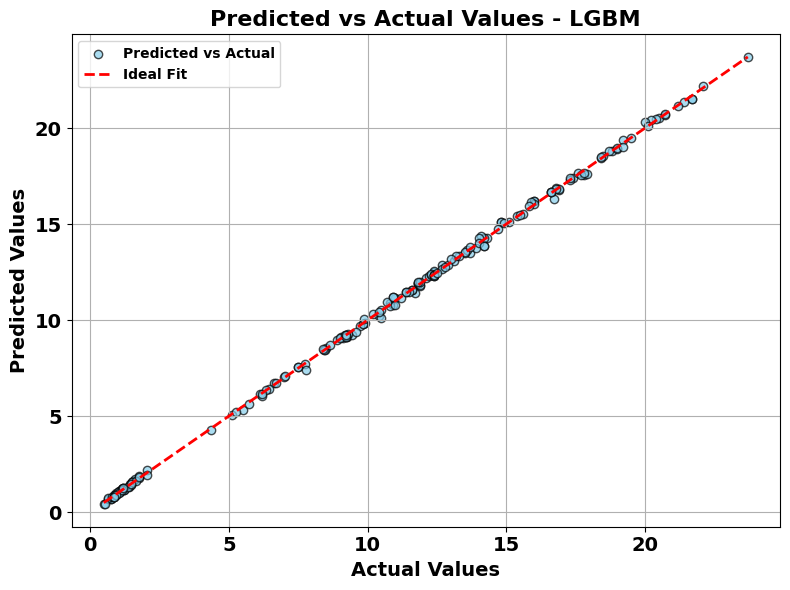

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

# Load your dataset
# Example: df = pd.read_csv("/content/drive/MyDrive/solar/solar3/your_dataset.csv")
# Make sure the target column is named "Efficiency"

# Define features and target
X = df.drop(columns=["Efficiency"])
y = df["Efficiency"]

# Split the dataset into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# LightGBM Regressor with GridSearchCV
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [-1, 10, 20],
    "learning_rate": [0.01, 0.1],
    "num_leaves": [31, 50]
}

lgbm = lgb.LGBMRegressor(random_state=42)
grid_search = GridSearchCV(estimator=lgbm, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled_df, y_train)

# Best model and parameters
best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# Predict on train and test sets
y_train_pred = best_model.predict(X_train_scaled_df)
y_test_pred = best_model.predict(X_test_scaled_df)

# Evaluation function
def evaluate_model(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    explained_variance = explained_variance_score(y_true, y_pred)

    print(f"\n{dataset_name} Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"R² Score: {r2:.4f}")
    print(f"Explained Variance Score: {explained_variance:.4f}")

    return mse, rmse, mae, r2, explained_variance

# Evaluate on training data
train_metrics = evaluate_model(y_train, y_train_pred, "Training")

# Evaluate on test data
test_metrics = evaluate_model(y_test, y_test_pred, "Test")

# Overfitting check
if abs(train_metrics[3] - test_metrics[3]) < 0.05:
    print("\nThe model does not exhibit significant overfitting.")
else:
    print("\nThe model may be overfitting.")

# Plot predicted vs actual values for the model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, color='skyblue', edgecolor='black', alpha=0.7, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.title('Predicted vs Actual Values - LGBM', fontsize=16, fontweight='bold')
plt.xlabel('Actual Values', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Values', fontsize=14, fontweight='bold')
plt.legend(fontsize=16, prop={'weight': 'bold'})
plt.grid(True)
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/solar3/True_vs_Predicted_LGBM.png", dpi=300)
plt.show()



# **CatBoost Regressor**

Best Parameters: {'depth': 6, 'iterations': 200, 'learning_rate': 0.1}

Training Metrics:
Mean Squared Error (MSE): 0.0008
Root Mean Squared Error (RMSE): 0.0281
Mean Absolute Error (MAE): 0.0208
R² Score: 1.0000
Explained Variance Score: 1.0000

Test Metrics:
Mean Squared Error (MSE): 0.0040
Root Mean Squared Error (RMSE): 0.0631
Mean Absolute Error (MAE): 0.0423
R² Score: 0.9999
Explained Variance Score: 0.9999

The model does not exhibit significant overfitting.


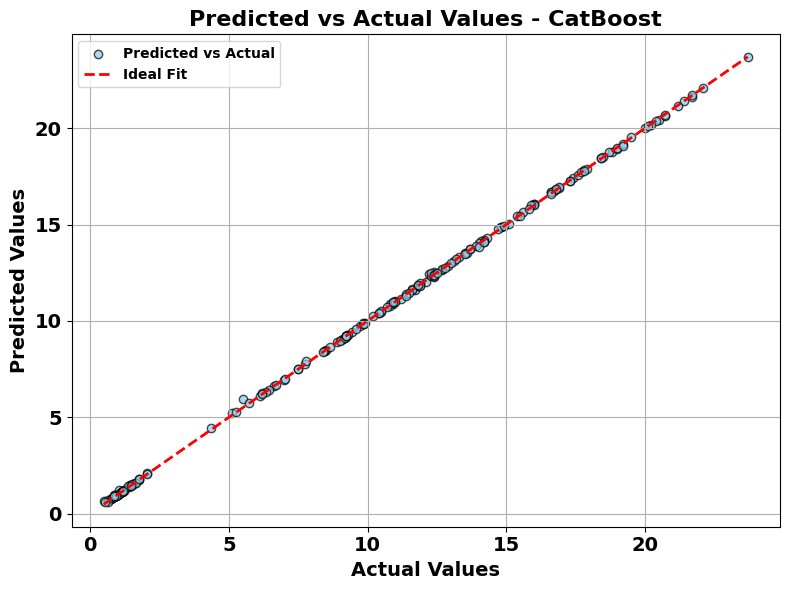

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor

# Load your dataset
# Example: df = pd.read_csv("/content/drive/MyDrive/solar/solar3/your_dataset.csv")
# Make sure the target column is named "Efficiency"

# Define features and target
X = df.drop(columns=["Efficiency"])
y = df["Efficiency"]

# Split the dataset into training (80%) and test (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# CatBoost Regressor with GridSearchCV
param_grid = {
    "iterations": [100, 200],
    "depth": [6, 10],
    "learning_rate": [0.01, 0.1]
}

catboost = CatBoostRegressor(random_state=42, verbose=0)
grid_search = GridSearchCV(estimator=catboost, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_scaled_df, y_train)

# Best model and parameters
best_model = grid_search.best_estimator_
print("Best Parameters:", grid_search.best_params_)

# Predict on train and test sets
y_train_pred = best_model.predict(X_train_scaled_df)
y_test_pred = best_model.predict(X_test_scaled_df)

# Evaluation function
def evaluate_model(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    explained_variance = explained_variance_score(y_true, y_pred)

    print(f"\n{dataset_name} Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"R² Score: {r2:.4f}")
    print(f"Explained Variance Score: {explained_variance:.4f}")

    return mse, rmse, mae, r2, explained_variance

# Evaluate on training data
train_metrics = evaluate_model(y_train, y_train_pred, "Training")

# Evaluate on test data
test_metrics = evaluate_model(y_test, y_test_pred, "Test")

# Overfitting check
if abs(train_metrics[3] - test_metrics[3]) < 0.05:
    print("\nThe model does not exhibit significant overfitting.")
else:
    print("\nThe model may be overfitting.")

# Plot predicted vs actual values for the model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, color='skyblue', edgecolor='black', alpha=0.7, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.title('Predicted vs Actual Values - CatBoost', fontsize=16, fontweight='bold')
plt.xlabel('Actual Values', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Values', fontsize=14, fontweight='bold')
plt.legend(fontsize=16, prop={'weight': 'bold'})
plt.grid(True)
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/solar3/True_vs_Predicted_CatBoost.png", dpi=300)
plt.show()


In [ ]:
pip install catboost

In [ ]:
pip install keras-tuner


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.4 MB/s eta 0:00:00


# **Deep Neural Network**

Trial 10 Complete [00h 00m 13s]
val_loss: 18.735336303710938

Best val_loss So Far: 12.404476165771484
Total elapsed time: 00h 02m 52s

Best Hyperparameters:
num_layers: 1
units_0: 160
activation: tanh
learning_rate: 0.01
units_1: 96
units_2: 224
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

Training Metrics:
Mean Squared Error (MSE): 12.5059
Root Mean Squared Error (RMSE): 3.5364
Mean Absolute Error (MAE): 2.8621
R² Score: 0.6851
Explained Variance Score: 0.6851

Test Metrics:
Mean Squared Error (MSE): 12.9249
Root Mean Squared Error (RMSE): 3.5951
Mean Absolute Error (MAE): 2.8700
R² Score: 0.6751
Explained Variance Score: 0.6751

The model does not exhibit significant overfitting.


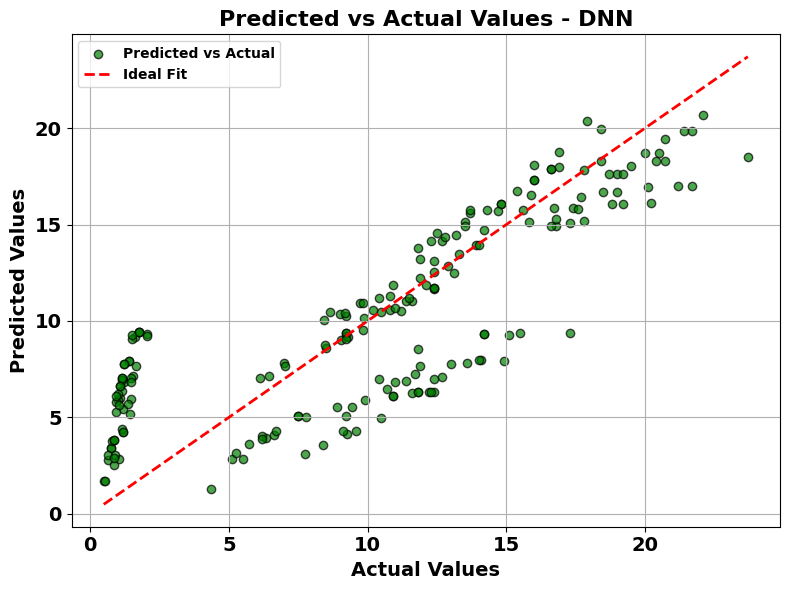

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import keras_tuner as kt

# Load your dataset
# Example: df = pd.read_csv("/content/drive/MyDrive/solar/solar3/your_dataset.csv")

# Define features and target
X = df.drop(columns=["Efficiency"])
y = df["Efficiency"]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Build model with hyperparameter tuning
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.InputLayer(input_shape=(X_train_scaled_df.shape[1],)))

    # Tune number of layers
    for i in range(hp.Int("num_layers", 1, 3)):
        model.add(layers.Dense(
            units=hp.Int(f"units_{i}", min_value=32, max_value=256, step=32),
            activation=hp.Choice("activation", ["relu", "tanh"])
        ))

    model.add(layers.Dense(1))  # Output layer
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Choice("learning_rate", [1e-2, 1e-3, 1e-4])
        ),
        loss="mse",
        metrics=["mae"]
    )
    return model

# Initialize tuner
tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=10,
    executions_per_trial=1,
    overwrite=True,
    directory="tuner_dir",
    project_name="dnn_regression"
)

# Early stopping
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Run tuner
tuner.search(X_train_scaled_df, y_train, validation_split=0.2, epochs=100, batch_size=32, callbacks=[early_stop], verbose=1)

# Get best model
best_model = tuner.get_best_models(num_models=1)[0]

# Show best hyperparameters
best_hps = tuner.get_best_hyperparameters(1)[0]
print("\nBest Hyperparameters:")
for key in best_hps.values.keys():
    print(f"{key}: {best_hps.get(key)}")

# Predict
y_train_pred = best_model.predict(X_train_scaled_df).flatten()
y_test_pred = best_model.predict(X_test_scaled_df).flatten()

# Evaluation
def evaluate_model(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    explained_variance = explained_variance_score(y_true, y_pred)

    print(f"\n{dataset_name} Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"R² Score: {r2:.4f}")
    print(f"Explained Variance Score: {explained_variance:.4f}")

    return mse, rmse, mae, r2, explained_variance

train_metrics = evaluate_model(y_train, y_train_pred, "Training")
test_metrics = evaluate_model(y_test, y_test_pred, "Test")

if abs(train_metrics[3] - test_metrics[3]) < 0.05:
    print("\nThe model does not exhibit significant overfitting.")
else:
    print("\nThe model may be overfitting.")

# Plot predicted vs actual values for the model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, color='green', edgecolor='black', alpha=0.7, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.title('Predicted vs Actual Values - DNN', fontsize=16, fontweight='bold')
plt.xlabel('Actual Values', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Values', fontsize=14, fontweight='bold')
plt.legend(fontsize=16, prop={'weight': 'bold'})
plt.grid(True)
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/solar3/True_vs_Predicted_DNN_Tuned.png", dpi=300)
plt.show()



# **CNN Regressor**

Trial 10 Complete [00h 00m 10s]
val_loss: 12.743107795715332

Best val_loss So Far: 12.30861759185791
Total elapsed time: 00h 02m 38s

Best Hyperparameters:
{'filters1': 128, 'kernel_size1': 3, 'filters2': 64, 'kernel_size2': 3, 'dense_units': 32, 'learning_rate': 0.01}
 1/26 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

Training Metrics:
Mean Squared Error (MSE): 11.6987
Root Mean Squared Error (RMSE): 3.4203
Mean Absolute Error (MAE): 2.6278
R² Score: 0.7054
Explained Variance Score: 0.7055

Test Metrics:
Mean Squared Error (MSE): 12.3745
Root Mean Squared Error (RMSE): 3.5177
Mean Absolute Error (MAE): 2.7113
R² Score: 0.6890
Explained Variance Score: 0.6891

The model does not exhibit significant overfitting.


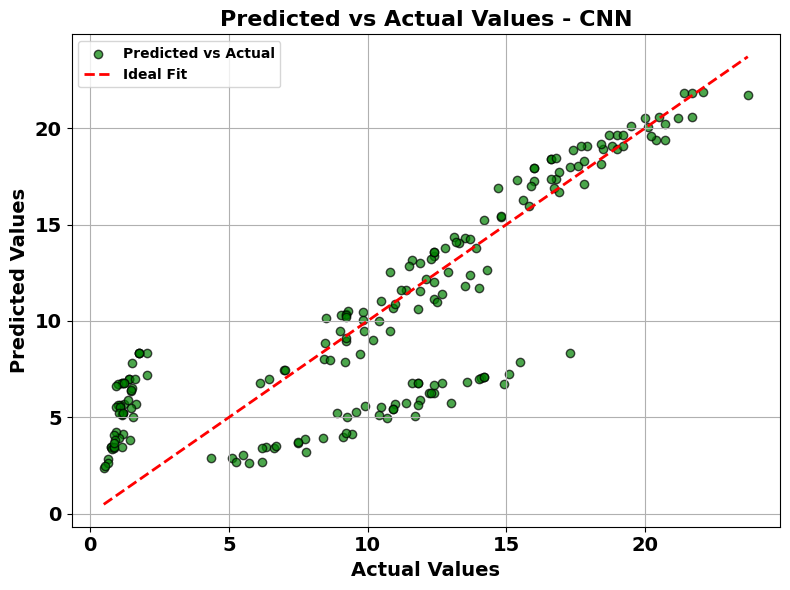

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
import matplotlib.pyplot as plt
import keras_tuner as kt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Load dataset
# df = pd.read_csv("/content/drive/MyDrive/solar3/your_dataset.csv")

# Features and target
X = df.drop(columns=["Efficiency"])
y = df["Efficiency"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for CNN
X_train_cnn = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_cnn = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

# Build model function for tuner
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Conv1D(
        filters=hp.Int('filters1', min_value=32, max_value=128, step=32),
        kernel_size=hp.Choice('kernel_size1', [2, 3]),
        activation='relu',
        input_shape=(X_train_cnn.shape[1], 1)
    ))
    model.add(layers.Conv1D(
        filters=hp.Int('filters2', min_value=32, max_value=128, step=32),
        kernel_size=hp.Choice('kernel_size2', [2, 3]),
        activation='relu'
    ))
    model.add(layers.Flatten())
    model.add(layers.Dense(
        units=hp.Int('dense_units', min_value=32, max_value=128, step=32),
        activation='relu'
    ))
    model.add(layers.Dense(1))

    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
        ),
        loss='mse',
        metrics=['mae']
    )
    return model

# Tuner setup
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory='cnn_tuner_dir',
    project_name='cnn_regressor'
)

# Tuning
tuner.search(X_train_cnn, y_train, validation_split=0.2, epochs=100, batch_size=32,
             callbacks=[tf.keras.callbacks.EarlyStopping(patience=10)], verbose=1)

# Best model
best_model = tuner.get_best_models(1)[0]
best_hyperparams = tuner.get_best_hyperparameters(1)[0]
print("\nBest Hyperparameters:")
print(best_hyperparams.values)

# Predict
y_train_pred = best_model.predict(X_train_cnn).flatten()
y_test_pred = best_model.predict(X_test_cnn).flatten()

# Evaluation
def evaluate_model(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    explained_variance = explained_variance_score(y_true, y_pred)

    print(f"\n{dataset_name} Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"R² Score: {r2:.4f}")
    print(f"Explained Variance Score: {explained_variance:.4f}")
    return mse, rmse, mae, r2, explained_variance

# Train/test evaluation
train_metrics = evaluate_model(y_train, y_train_pred, "Training")
test_metrics = evaluate_model(y_test, y_test_pred, "Test")

# Overfitting check
if abs(train_metrics[3] - test_metrics[3]) < 0.05:
    print("\nThe model does not exhibit significant overfitting.")
else:
    print("\nThe model may be overfitting.")

# Plot predicted vs actual values for the model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, color='green', edgecolor='black', alpha=0.7, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.title('Predicted vs Actual Values - CNN', fontsize=16, fontweight='bold')
plt.xlabel('Actual Values', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Values', fontsize=14, fontweight='bold')
plt.legend(fontsize=16, prop={'weight': 'bold'})
plt.grid(True)
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/solar3/True_vs_Predicted_CNN_Tuned.png", dpi=300)
plt.show()


# **LSTM Regressor**

Trial 10 Complete [00h 00m 33s]
val_loss: 13.244260787963867

Best val_loss So Far: 12.223098754882812
Total elapsed time: 00h 05m 37s


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Best Hyperparameters:
{'lstm_units1': 96, 'lstm_units2': 32, 'dense_units': 128, 'learning_rate': 0.01}
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

Training Metrics:
Mean Squared Error (MSE): 11.6805
Root Mean Squared Error (RMSE): 3.4177
Mean Absolute Error (MAE): 2.6564
R² Score: 0.7059
Explained Variance Score: 0.7059

Test Metrics:
Mean Squared Error (MSE): 12.0965
Root Mean Squared Error (RMSE): 3.4780
Mean Absolute Error (MAE): 2.7135
R² Score: 0.6959
Explained Variance Score: 0.6960

The model does not exhibit significant overfitting.


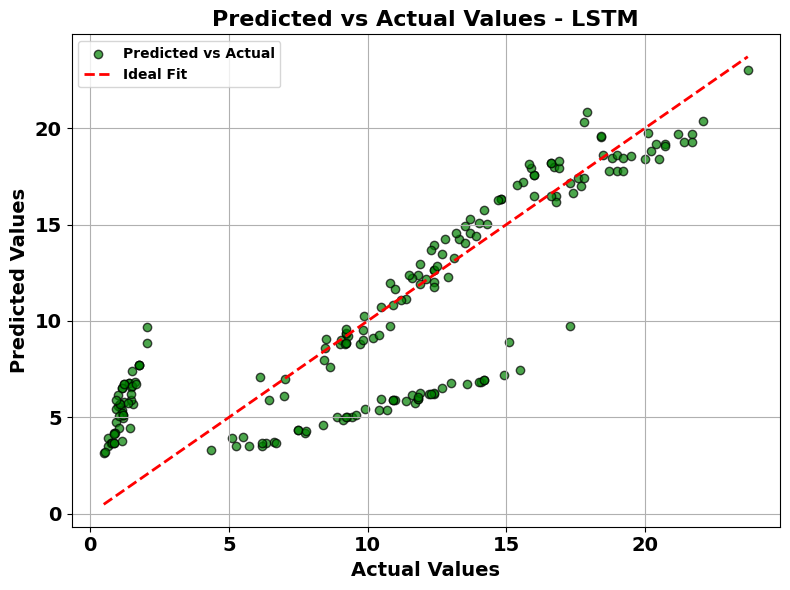

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
import matplotlib.pyplot as plt
import keras_tuner as kt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Load dataset
# df = pd.read_csv("/content/drive/MyDrive/solar3/your_dataset.csv")

# Features and target
X = df.drop(columns=["Efficiency"])
y = df["Efficiency"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for LSTM
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], X_train_scaled.shape[1], 1))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], X_test_scaled.shape[1], 1))

# Build model function for tuner
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.LSTM(
        units=hp.Int('lstm_units1', min_value=32, max_value=128, step=32),
        return_sequences=True,
        input_shape=(X_train_lstm.shape[1], 1)
    ))
    model.add(layers.LSTM(
        units=hp.Int('lstm_units2', min_value=32, max_value=128, step=32),
        return_sequences=False
    ))
    model.add(layers.Dense(
        units=hp.Int('dense_units', min_value=32, max_value=128, step=32),
        activation='relu'
    ))
    model.add(layers.Dense(1))

    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
        ),
        loss='mse',
        metrics=['mae']
    )
    return model

# Tuner setup
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory='lstm_tuner_dir',
    project_name='lstm_regressor'
)

# Tuning
tuner.search(X_train_lstm, y_train, validation_split=0.2, epochs=100, batch_size=32,
             callbacks=[tf.keras.callbacks.EarlyStopping(patience=10)], verbose=1)

# Best model
best_model = tuner.get_best_models(1)[0]
best_hyperparams = tuner.get_best_hyperparameters(1)[0]
print("\nBest Hyperparameters:")
print(best_hyperparams.values)

# Predict
y_train_pred = best_model.predict(X_train_lstm).flatten()
y_test_pred = best_model.predict(X_test_lstm).flatten()

# Evaluation
def evaluate_model(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    explained_variance = explained_variance_score(y_true, y_pred)

    print(f"\n{dataset_name} Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"R² Score: {r2:.4f}")
    print(f"Explained Variance Score: {explained_variance:.4f}")
    return mse, rmse, mae, r2, explained_variance

# Train/test evaluation
train_metrics = evaluate_model(y_train, y_train_pred, "Training")
test_metrics = evaluate_model(y_test, y_test_pred, "Test")

# Overfitting check
if abs(train_metrics[3] - test_metrics[3]) < 0.05:
    print("\nThe model does not exhibit significant overfitting.")
else:
    print("\nThe model may be overfitting.")

# Plot predicted vs actual values for the model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, color='green', edgecolor='black', alpha=0.7, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.title('Predicted vs Actual Values - LSTM', fontsize=16, fontweight='bold')
plt.xlabel('Actual Values', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Values', fontsize=14, fontweight='bold')
plt.legend(fontsize=16, prop={'weight': 'bold'})
plt.grid(True)
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/solar3/True_vs_Predicted_LSTM_Tuned.png", dpi=300)
plt.show()



# **ANN**

Trial 10 Complete [00h 00m 25s]
val_loss: 27.76291847229004

Best val_loss So Far: 12.060477256774902
Total elapsed time: 00h 03m 23s


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Best Hyperparameters:
{'dense_units1': 32, 'dense_units2': 96, 'learning_rate': 0.01}
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

Training Metrics:
Mean Squared Error (MSE): 11.4005
Root Mean Squared Error (RMSE): 3.3765
Mean Absolute Error (MAE): 2.5162
R² Score: 0.7129
Explained Variance Score: 0.7143

Test Metrics:
Mean Squared Error (MSE): 12.2760
Root Mean Squared Error (RMSE): 3.5037
Mean Absolute Error (MAE): 2.6000
R² Score: 0.6914
Explained Variance Score: 0.6928

The model does not exhibit significant overfitting.


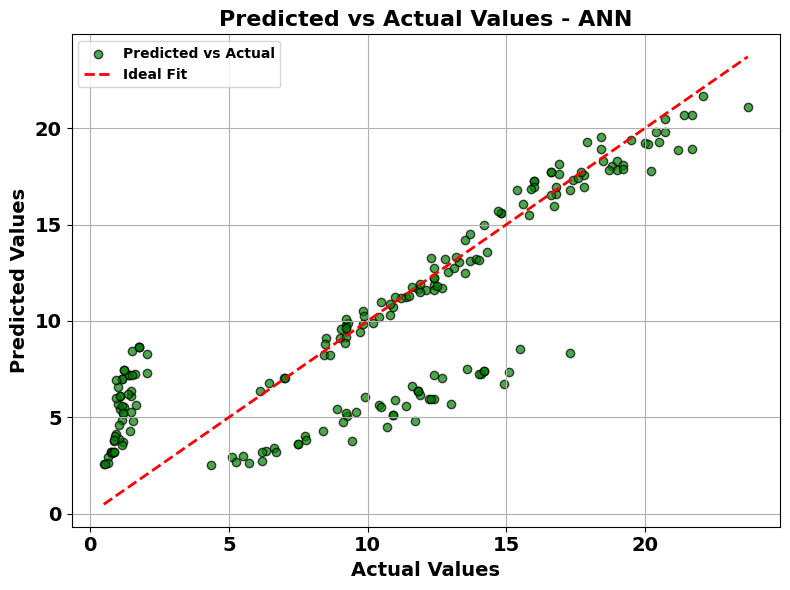

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
import matplotlib.pyplot as plt
import keras_tuner as kt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Load dataset
# df = pd.read_csv("/content/drive/MyDrive/solar3/your_dataset.csv")

# Features and target
X = df.drop(columns=["Efficiency"])
y = df["Efficiency"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build model function for tuner
def build_model(hp):
    model = keras.Sequential()
    # First hidden layer
    model.add(layers.Dense(
        units=hp.Int('dense_units1', min_value=32, max_value=128, step=32),
        activation='relu',
        input_dim=X_train_scaled.shape[1]
    ))
    # Second hidden layer
    model.add(layers.Dense(
        units=hp.Int('dense_units2', min_value=32, max_value=128, step=32),
        activation='relu'
    ))
    # Output layer
    model.add(layers.Dense(1))

    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])
        ),
        loss='mse',
        metrics=['mae']
    )
    return model

# Tuner setup
tuner = kt.RandomSearch(
    build_model,
    objective='val_loss',
    max_trials=10,
    executions_per_trial=1,
    directory='ann_tuner_dir',
    project_name='ann_regressor'
)

# Tuning
tuner.search(X_train_scaled, y_train, validation_split=0.2, epochs=100, batch_size=32,
             callbacks=[tf.keras.callbacks.EarlyStopping(patience=10)], verbose=1)

# Best model
best_model = tuner.get_best_models(1)[0]
best_hyperparams = tuner.get_best_hyperparameters(1)[0]
print("\nBest Hyperparameters:")
print(best_hyperparams.values)

# Predict
y_train_pred = best_model.predict(X_train_scaled).flatten()
y_test_pred = best_model.predict(X_test_scaled).flatten()

# Evaluation
def evaluate_model(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    explained_variance = explained_variance_score(y_true, y_pred)

    print(f"\n{dataset_name} Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"R² Score: {r2:.4f}")
    print(f"Explained Variance Score: {explained_variance:.4f}")
    return mse, rmse, mae, r2, explained_variance

# Train/test evaluation
train_metrics = evaluate_model(y_train, y_train_pred, "Training")
test_metrics = evaluate_model(y_test, y_test_pred, "Test")

# Overfitting check
if abs(train_metrics[3] - test_metrics[3]) < 0.05:
    print("\nThe model does not exhibit significant overfitting.")
else:
    print("\nThe model may be overfitting.")

# Plot predicted vs actual values for the model
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, color='green', edgecolor='black', alpha=0.7, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.title('Predicted vs Actual Values - ANN', fontsize=16, fontweight='bold')
plt.xlabel('Actual Values', fontsize=14, fontweight='bold')
plt.ylabel('Predicted Values', fontsize=14, fontweight='bold')
plt.legend(fontsize=16, prop={'weight': 'bold'})
plt.grid(True)
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/solar3/True_vs_Predicted_ANN_Tuned.png", dpi=300)
plt.show()


In [ ]:
pip install keras-tuner


In [ ]:
pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 5.3 MB/s eta 0:00:00


In [ ]:
pip install tensorflow==2.11.0


In [ ]:
pip install --upgrade tensorflow


In [ ]:
pip install scikeras


In [ ]:
pip install --upgrade scikit-learn scikeras



In [ ]:
pip install scikeras


# **SHAP**

In [ ]:
import shap
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

# Set all font text to bold globally for matplotlib
matplotlib.rcParams.update({
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 14,
    'ytick.labelsize': 14
})

# 1. Initialize SHAP Explainer
explainer = shap.Explainer(best_model, X_train_scaled_df)

# 2. Compute SHAP values
shap_values = explainer(X_test_scaled_df)

# 3. Summary Bar Plot
shap.summary_plot(shap_values, X_test_scaled_df, plot_type="bar", show=False)
fig = plt.gcf()  # Get current figure
fig.set_size_inches(12, 6)  # Set desired size
plt.title("SHAP Summary Plot (Bar)", fontweight='bold')  # Set title
fig.subplots_adjust(bottom=0.3)  # Ensure x-axis labels are not cut off
fig.savefig("/content/drive/MyDrive/solar3/SHAP_Summary_Bar_XGB1.png", dpi=300, bbox_inches="tight")
plt.close()

# 4. Summary Beeswarm Plot
shap.summary_plot(shap_values, X_test_scaled_df, plot_type="dot", show=False)
fig = plt.gcf()
plt.title("SHAP Summary Plot (Beeswarm)", fontweight='bold')
fig.set_size_inches(10, 6)
fig.tight_layout()
fig.savefig("/content/drive/MyDrive/solar3/SHAP_Summary_Beeswarm_XGB.png", dpi=300)
plt.close()

# 5. Dependence Plot
shap.dependence_plot(
    "Absorber defect density",
    shap_values.values,
    X_test_scaled_df,
    show=False
)
fig = plt.gcf()
plt.title("SHAP Dependence: Absorber Defect Density", fontweight='bold')
plt.xlabel("Absorber defect density", fontweight='bold')
plt.ylabel("SHAP value", fontweight='bold')
fig.tight_layout()
fig.savefig("/content/drive/MyDrive/solar3/SHAP_Dependence_AbsorberDefect_XGB.png", dpi=300)
plt.close()

# 6. Force Plot (interactive)
shap.initjs()
i = 0
force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[i].values,
    X_test_scaled_df.iloc[i],
    feature_names=X_test_scaled_df.columns
)
shap.save_html("/content/drive/MyDrive/solar3/SHAP_Force_Instance0_XGB.html", force_plot)


In [ ]:
import pandas as pd

# Define the instances and your actual feature names
selected_instances = list(range(10))  # Instances 0 to 9
selected_features = [
    "Absorber defect density",
    "Series resistance",
    "Shunt resistance",
    "Reflection",
    "Radiative recombination"
]

# Initialize the table
shap_table = pd.DataFrame(columns=["Instance"] + selected_features)

# Extract SHAP values for the selected instances and features
for i in selected_instances:
    row = {"Instance": i}
    for feature in selected_features:
        row[feature] = shap_values[i, X_test_scaled_df.columns.get_loc(feature)].values
    shap_table = pd.concat([shap_table, pd.DataFrame([row])], ignore_index=True)

# Save to Excel
shap_table.to_excel("/content/drive/MyDrive/solar3/SHAP_Table_Your_Features.xlsx", index=False)

# Print the table (optional)
shap_table


<ipython-input-16-80105ab19123>:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  shap_table = pd.concat([shap_table, pd.DataFrame([row])], ignore_index=True)


,Instance,Absorber defect density,Series resistance,Shunt resistance,Reflection,Radiative recombination
0,0,0.023022,0.468696,-7.786917,-0.658895,0.001081
1,1,1.084043,0.174149,4.952114,0.248882,-0.639100
2,2,0.947115,-0.180830,3.966935,-0.950882,-4.397492
3,3,1.268819,0.699500,0.599728,-1.501281,2.254818
4,4,-0.441087,0.149571,5.077546,-0.522230,2.190607
5,5,-0.102940,0.068475,-8.617778,-0.285591,1.001856
6,6,1.629762,-0.259212,5.521442,-1.351931,2.712505
7,7,-0.194474,-0.458910,0.861868,-1.203230,1.766662
8,8,0.509659,0.060817,-6.499935,-0.557284,-1.886240
9,9,-0.100699,-0.330784,-8.350542,-0.266162,0.973870
